# DO Masked Card Classifier Test Notebook

Run scene segmentation, detect card crops, classify each crop with a mask-conditioned classifier, and group predictions with fixed UNO geometry (`p1` bottom, `p2` right, `p3` top, `p4` left, center in the middle).

## Inference conventions

- This notebook is inference/evaluation only.
- It loads:
  - `project/models/scene_segmenter_unet_small.pth`
  - `project/models/card_classifier_masked_resnet18_do.pth`
  - `project/models/card_classifier_masked_resnet18_classes_do.npy`
  - `project/models/card_classifier_masked_resnet18_config_do.json`
- It does not use pretrained external weights and keeps the existing competition-compliant geometry mapping.

In [1]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd().parent.parent / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


from src.test_classifier_CNN import (
    TestPipelineConfig,
    initialize_test_pipeline,
    run_labeled_benchmark,
    run_single_image_diagnostics,
)

# Most-used quick knobs
IMAGE_SOURCE = "augmented_scene"
IMAGE_INDEX = 0
IMAGE_ID = None
SEGMENTATION_THRESHOLD = 0.50
CARD_MASK_THRESHOLD = 0.50
CARD_IMG_SIZE = 160
SEGMENTER_IMG_SIZE = 256
# Manual area filter on connected mask components (in pixels).
SEGMENTER_MIN_COMPONENT_AREA = 4000

EVAL_MAX_IMAGES = None
EVAL_RANDOM_SUBSET = True
EVAL_SEED = 42
WORST_K = 7
TOP_K = 7

TEST_CFG = TestPipelineConfig(
    image_source=IMAGE_SOURCE,
    image_index=IMAGE_INDEX,
    image_id=IMAGE_ID,
    card_img_size=CARD_IMG_SIZE,
    segmenter_img_size=SEGMENTER_IMG_SIZE,
    card_mask_threshold=CARD_MASK_THRESHOLD,
    segmenter_min_component_area=SEGMENTER_MIN_COMPONENT_AREA,
    eval_threshold=SEGMENTATION_THRESHOLD,
)

BENCHMARK_CFG = {
    "eval_max_images": EVAL_MAX_IMAGES,
    "eval_random_subset": EVAL_RANDOM_SUBSET,
    "eval_seed": EVAL_SEED,
    "eval_threshold": TEST_CFG.eval_threshold,
    "worst_k": WORST_K,
    "top_k": TOP_K,
}

TEST_CFG

TestPipelineConfig(image_source='augmented_scene', image_index=0, image_id=None, card_img_size=160, segmenter_img_size=256, card_mask_threshold=0.5, segmenter_min_component_area=4000, eval_threshold=0.5)

## Shared Helpers

In [2]:
test_state = initialize_test_pipeline(TEST_CFG)
{
    "image_id": test_state["image_id"],
    "image_path": str(test_state["image_path"]),
    "image_shape": (test_state["image_w"], test_state["image_h"]),
}

Project root: /Users/dorianbesson/EDOC/IA/iapr2026do
Segmenter:    /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/segmenter/used/scene_segmenter_unet_small.pth
Classifier bundle: /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_classifier_cnn/used/latest
Classifier:   /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_classifier_cnn/used/latest/card_classifier.pth
[compliance] SceneUNetSmall (segmenter): 1,928,417 trainable params
[compliance] CardClassifier[resnet18_small]: 9,853,134 trainable params
Loaded masked classifier with 54 classes.
Classifier architecture: resnet18_small (stem_width=60)
Card image size: 160 | mask threshold: 0.5 | segmenter min component area: 4000 | input channels: 4
Device: cpu
Image source: augmented_scene
Image id:     aug_scene_00000
Image shape:  1280 x 720
Truth cards:  18, active: p4


{'image_id': 'aug_scene_00000',
 'image_path': '/Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/augmented_scenes/aug_scene_00000.jpg',
 'image_shape': (1280, 720)}

## Segmenter Helpers

Detected boxes: 11
Foreground pixels: 115909


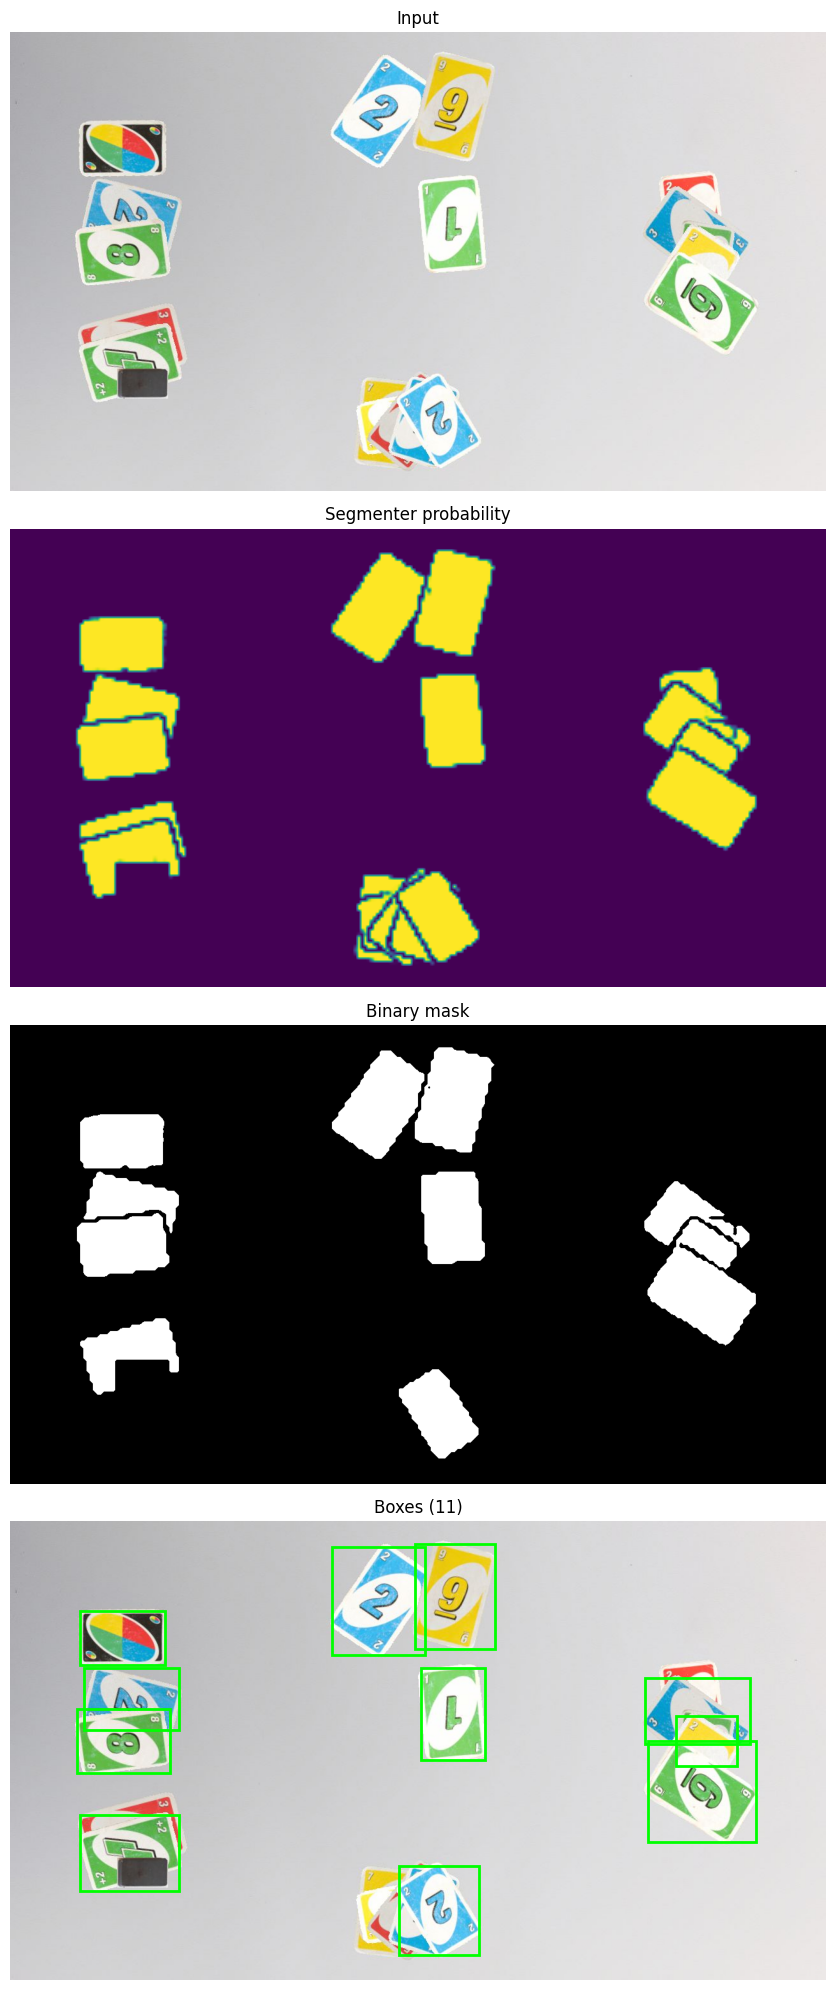

Predictions:
  box 00 (1000, 345, 1170, 503) -> g_6 [p2] conf=0.94 mask_cov=0.46
  box 01 (505, 40, 650, 210) -> b_2 [p3] conf=0.94 mask_cov=0.42
  box 02 (635, 35, 760, 200) -> y_9 [p3] conf=0.86 mask_cov=0.44
  box 03 (110, 460, 265, 580) -> g_draw_2 [p4] conf=0.92 mask_cov=0.30
  box 04 (610, 540, 735, 680) -> b_2 [p1] conf=0.98 mask_cov=0.38
  box 05 (995, 245, 1160, 350) -> b_4 [p2] conf=0.20 mask_cov=0.29
  box 06 (115, 230, 265, 327) -> b_2 [p4] conf=0.85 mask_cov=0.43
  box 07 (645, 230, 745, 375) -> g_1 [center] conf=0.85 mask_cov=0.44
  box 08 (105, 295, 250, 395) -> g_8 [p4] conf=0.87 mask_cov=0.48
  box 09 (110, 140, 242, 225) -> wild [p4] conf=0.94 mask_cov=0.45
  box 10 (1045, 305, 1140, 384) -> wild [p2] conf=0.31 mask_cov=0.64


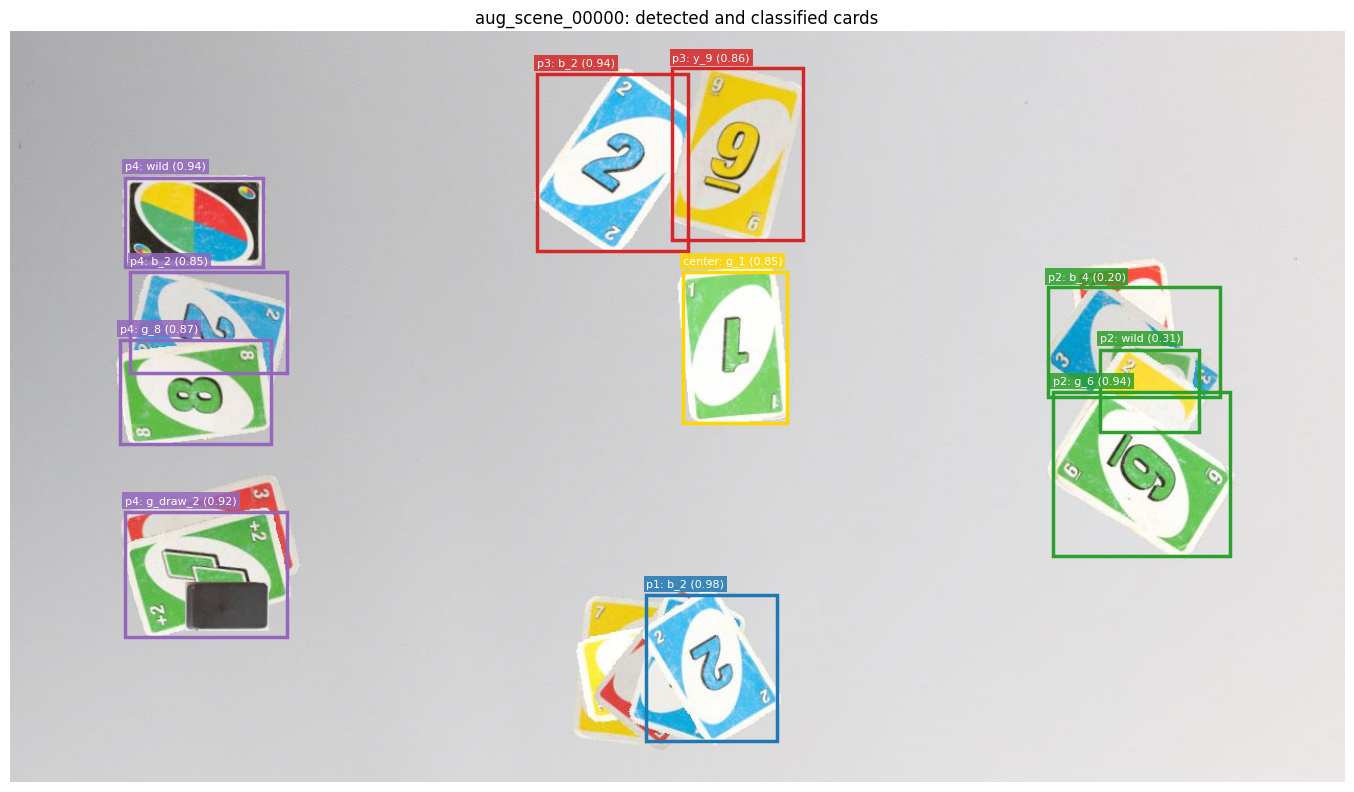


Matched IoU >= 0.30: 11 / 11
Label accuracy on matched boxes:        81.8%
Owner/region accuracy on matched boxes: 100.0%

First matched rows:
  pred=p2     g_6          | truth=p2     g_6          | IoU=0.94
  pred=p3     b_2          | truth=p3     b_2          | IoU=0.87
  pred=p3     y_9          | truth=p3     y_9          | IoU=0.92
  pred=p4     g_draw_2     | truth=p4     g_draw_2     | IoU=0.93
  pred=p1     b_2          | truth=p1     b_2          | IoU=0.89
  pred=p2     b_4          | truth=p2     b_3          | IoU=0.62
  pred=p4     b_2          | truth=p4     b_2          | IoU=0.79
  pred=center g_1          | truth=center g_1          | IoU=0.89
  pred=p4     g_8          | truth=p4     g_8          | IoU=0.91
  pred=p4     wild         | truth=p4     wild         | IoU=0.91
  pred=p2     wild         | truth=p2     g_4          | IoU=0.50
image_id: aug_scene_00000
center_card: g_1
active_player: p4
player_1_cards: b_2
player_2_cards: g_6;b_4;wild
player_3_cards: b_2;

{'image_id': 'aug_scene_00000',
 'center_card': 'g_1',
 'active_player': 'p4',
 'player_1_cards': 'b_2',
 'player_2_cards': 'g_6;b_4;wild',
 'player_3_cards': 'b_2;y_9',
 'player_4_cards': 'g_draw_2;b_2;g_8;wild'}

In [3]:
test_state = run_single_image_diagnostics(test_state, threshold=TEST_CFG.eval_threshold)
test_state.get("summary", {})

## Load Segmenter + Masked Classifier And Pick An Image

In [4]:
test_state.get("pred_rows", [])[:10]

[{'box_index': 0,
  'box': (1000, 345, 1170, 503),
  'label': 'g_6',
  'confidence': 0.936777651309967,
  'region': 'p2',
  'mask_coverage': 0.464453125},
 {'box_index': 1,
  'box': (505, 40, 650, 210),
  'label': 'b_2',
  'confidence': 0.9429313540458679,
  'region': 'p3',
  'mask_coverage': 0.4191015625},
 {'box_index': 2,
  'box': (635, 35, 760, 200),
  'label': 'y_9',
  'confidence': 0.8618419170379639,
  'region': 'p3',
  'mask_coverage': 0.4416015625},
 {'box_index': 3,
  'box': (110, 460, 265, 580),
  'label': 'g_draw_2',
  'confidence': 0.9188453555107117,
  'region': 'p4',
  'mask_coverage': 0.2965234375},
 {'box_index': 4,
  'box': (610, 540, 735, 680),
  'label': 'b_2',
  'confidence': 0.9778485894203186,
  'region': 'p1',
  'mask_coverage': 0.3790625},
 {'box_index': 5,
  'box': (995, 245, 1160, 350),
  'label': 'b_4',
  'confidence': 0.19512414932250977,
  'region': 'p2',
  'mask_coverage': 0.2880078125},
 {'box_index': 6,
  'box': (115, 230, 265, 327),
  'label': 'b_2',
 

In [5]:
test_state.get("summary", {})

{'image_id': 'aug_scene_00000',
 'center_card': 'g_1',
 'active_player': 'p4',
 'player_1_cards': 'b_2',
 'player_2_cards': 'g_6;b_4;wild',
 'player_3_cards': 'b_2;y_9',
 'player_4_cards': 'g_draw_2;b_2;g_8;wild'}

## Segment Cards

In [6]:
BENCHMARK_CFG

{'eval_max_images': None,
 'eval_random_subset': True,
 'eval_seed': 42,
 'eval_threshold': 0.5,
 'worst_k': 7,
 'top_k': 7}

## Classify Masked Card Crops And Group By Table Geometry

Evaluating on 71 labeled original images from /Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train.csv...
  processed 25/71
  processed 50/71
  processed 71/71

Benchmark summary (masked classifier on original labeled data):
  Center-card accuracy: 95.77%
  Player F1: p1=0.793, p2=0.785, p3=0.788, p4=0.802
  Macro player F1: 0.792
  Overall image score:  0.825
  Overall strict score: 0.808 (includes segmenter count-variation quality)
  Segmenter avg |pred-true| cards/image: 0.775
  Segmenter avg (pred-true) cards/image: 0.493
  Segmenter avg region variation/image:  1.113
  Segmenter total cards: pred=591, true=556
  Segmenter count-quality score: 0.722
  Note: active_player is not scored yet (not predicted by this pipeline).


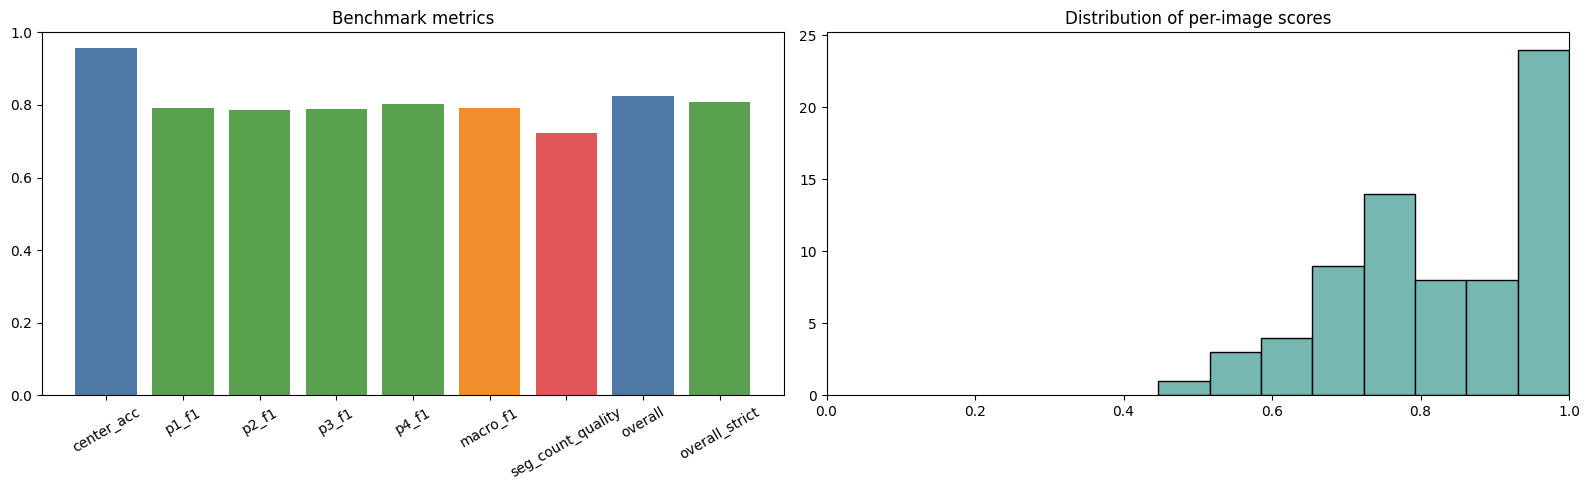


Worst-performing labeled images:
  L1000981: score=0.447, center(pred/true)=b_5/b_5
  L1000850: score=0.520, center(pred/true)=g_2/g_2
  L1000975: score=0.527, center(pred/true)=y_3/y_3
  L1000974: score=0.580, center(pred/true)=r_8/r_8
  L1000847: score=0.600, center(pred/true)=g_8/g_8
  L1000979: score=0.600, center(pred/true)=r_0/r_0
  L1000973: score=0.613, center(pred/true)=b_2/b_2

Top-performing labeled images:
  L1000770: score=1.000, center(pred/true)=y_1/y_1
  L1000771: score=1.000, center(pred/true)=r_5/r_5
  L1000773: score=1.000, center(pred/true)=y_8/y_8
  L1000774: score=1.000, center(pred/true)=r_4/r_4
  L1000778: score=1.000, center(pred/true)=b_9/b_9
  L1000782: score=1.000, center(pred/true)=y_7/y_7
  L1000784: score=1.000, center(pred/true)=r_0/r_0


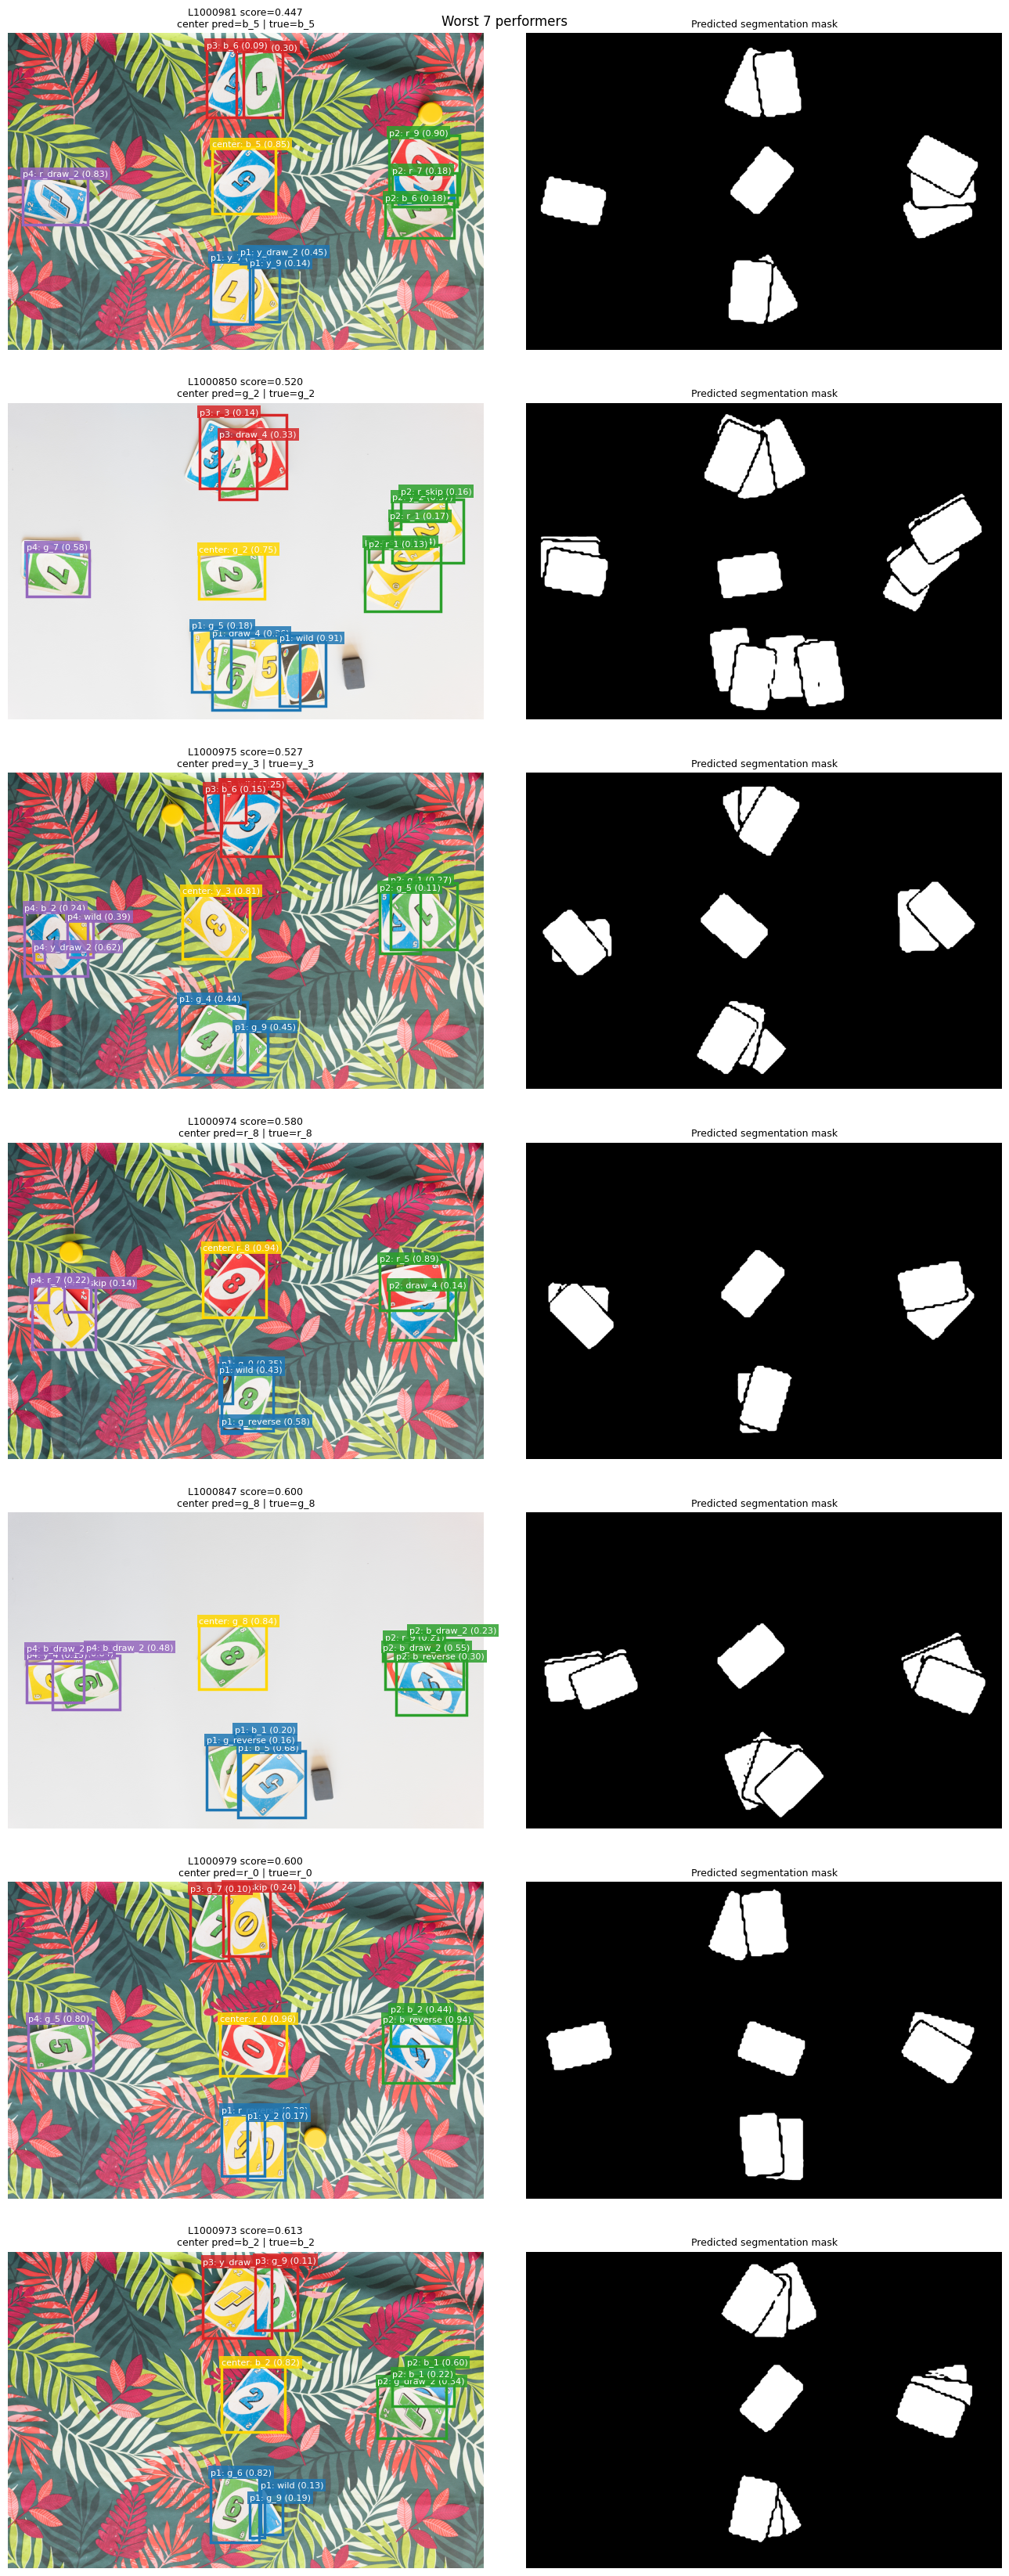

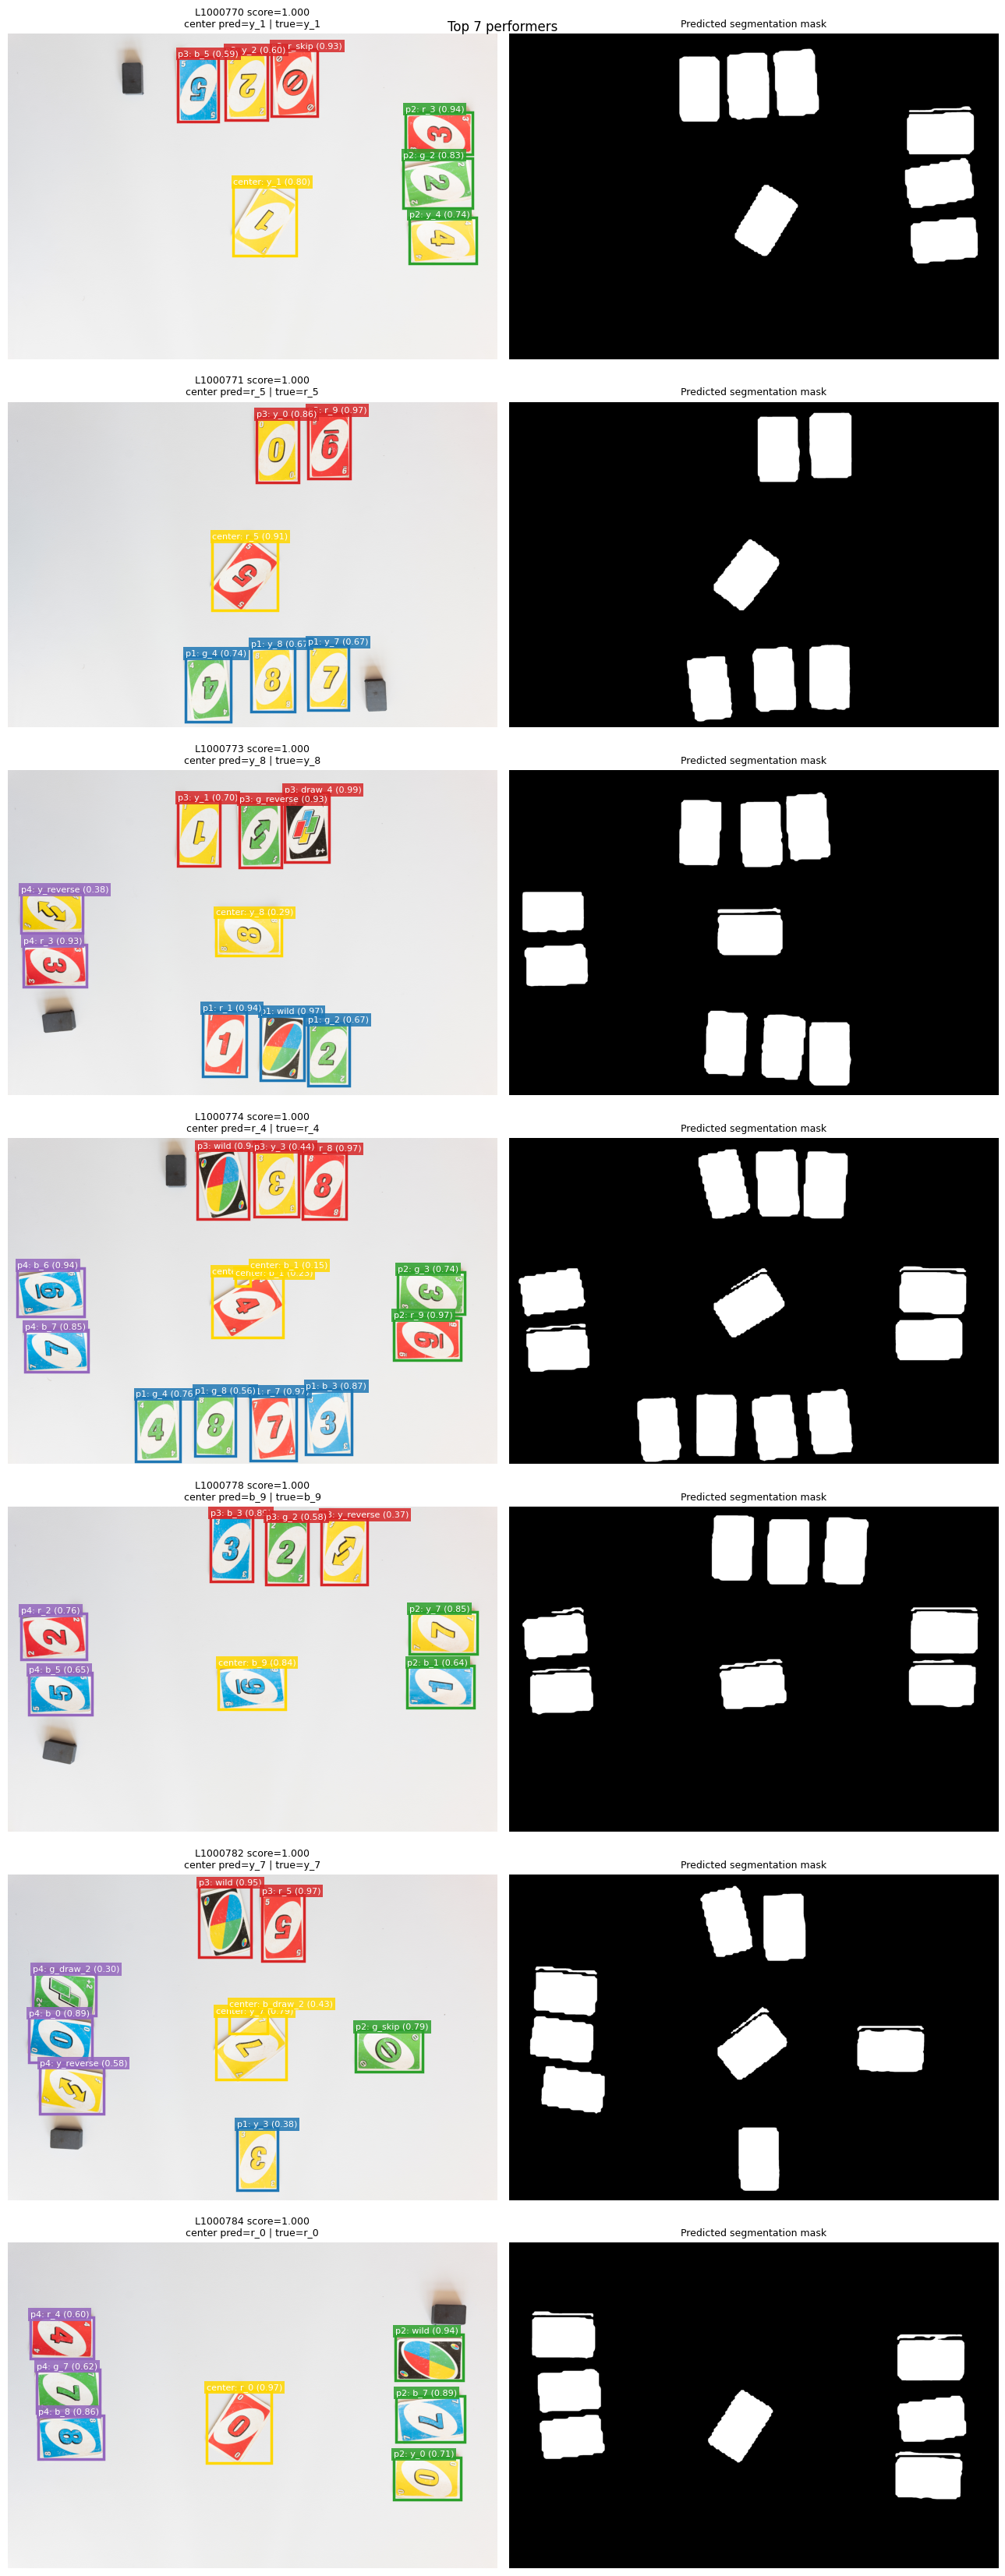

{'center_acc': 0.9577464788732394,
 'p1_f1': 0.7925553319919516,
 'p2_f1': 0.7854460093896714,
 'p3_f1': 0.7878269617706237,
 'p4_f1': 0.8020456069751845,
 'macro_f1': 0.7919684775318578,
 'overall': 0.825124077800134,
 'overall_strict': 0.8079476861167001,
 'segmenter_count_quality': 0.7220657276995305,
 'avg_abs_card_count_diff': 0.7746478873239436,
 'avg_signed_card_count_diff': 0.49295774647887325,
 'avg_region_abs_card_count_diff': 1.1126760563380282,
 'cards_total_true': 556,
 'cards_total_pred': 591}

In [7]:
benchmark = run_labeled_benchmark(test_state, BENCHMARK_CFG)
{
    key: benchmark[key]
    for key in [
        "center_acc", "p1_f1", "p2_f1", "p3_f1", "p4_f1",
        "macro_f1", "overall", "overall_strict",
        "segmenter_count_quality", "avg_abs_card_count_diff",
        "avg_signed_card_count_diff", "avg_region_abs_card_count_diff",
        "cards_total_true", "cards_total_pred",
    ]
}

## Synthetic-Scene Check

In [8]:
benchmark["worst_results"][:5]

[{'image_id': 'L1000981',
  'image_path': PosixPath('/Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train_images/L1000981.jpg'),
  'pred_summary': {'image_id': 'L1000981',
   'center_card': 'b_5',
   'active_player': 'unknown',
   'player_1_cards': 'y_7;y_9;y_draw_2',
   'player_2_cards': 'r_9;b_6;r_7',
   'player_3_cards': 'g_1;b_6',
   'player_4_cards': 'r_draw_2'},
  'true_summary': {'image_id': 'L1000981',
   'center_card': 'b_5',
   'active_player': 'p2',
   'player_1_cards': 'y_7;y_skip',
   'player_2_cards': 'g_7;b_4;r_9',
   'player_3_cards': 'b_5;g_1',
   'player_4_cards': 'b_draw_2'},
  'pred_rows': [{'box_index': 0,
    'box': (1719, 955, 2250, 1520),
    'label': 'b_5',
    'confidence': 0.8516368865966797,
    'region': 'center',
    'mask_coverage': 0.379375},
   {'box_index': 1,
    'box': (3203, 861, 3797, 1363),
    'label': 'r_9',
    'confidence': 0.8984097242355347,
    'region': 'p2',
    'mask_coverage': 0.4880078125},
   {'box_index': 2,

## Game-State Style Summary

This formats CardUNet predictions into the same game-state style row structure:
one center card and one card list per player (`p1..p4`). Active-player prediction remains handled by the turn/token detector.

In [9]:
benchmark["top_results"][:5]

[{'image_id': 'L1000770',
  'image_path': PosixPath('/Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train_images/L1000770.jpg'),
  'pred_summary': {'image_id': 'L1000770',
   'center_card': 'y_1',
   'active_player': 'unknown',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'g_2;y_4;r_3',
   'player_3_cards': 'r_skip;y_2;b_5',
   'player_4_cards': 'EMPTY'},
  'true_summary': {'image_id': 'L1000770',
   'center_card': 'y_1',
   'active_player': 'p3',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'y_4;g_2;r_3',
   'player_3_cards': 'r_skip;y_2;b_5',
   'player_4_cards': 'EMPTY'},
  'pred_rows': [{'box_index': 0,
    'box': (1844, 1237, 2359, 1818),
    'label': 'y_1',
    'confidence': 0.8026125431060791,
    'region': 'center',
    'mask_coverage': 0.3718359375},
   {'box_index': 1,
    'box': (3234, 1018, 3797, 1425),
    'label': 'g_2',
    'confidence': 0.8267397880554199,
    'region': 'p2',
    'mask_coverage': 0.434453125},
   {'box_index': 2,
  

## Benchmark On Original Labeled Dataset (Masked Classifier)

> The official `test_images` split has no public labels, so true performance cannot be computed there. This section evaluates the full segmentation + masked classification pipeline on labeled images from `train.csv` (optionally on a subset), reports metrics, and visualizes worst/top examples.

In [10]:
# # Optional quick benchmark rerun on a subset.
# quick_benchmark_cfg = {
#     **BENCHMARK_CFG,
#     "eval_max_images": 100,
# }
# quick_benchmark = run_labeled_benchmark(test_state, quick_benchmark_cfg)
# quick_benchmark["overall"]